# **Machine Learning Foundation Course Mini_project**

### **Done by: Leonard Sanya**

### **September 2025**

# **Abstract**

This project investigates the spatial distribution of healthcare facilities in Kenya and its relationship to population needs by integrating diverse datasets, including the 2019 Census population data, county boundary GeoJSON files, and healthcare facility records. Additional geographic features are extracted from OpenStreetMap to enrich the analysis. The study follows the *Access–Assess–Address* framework: data are accessed and preprocessed, assessed through exploratory data analysis, visualization, and correlation checks, and then addressed with predictive modeling. Logistic Regression and Naïve Bayes classifiers are applied to identify underserved regions, with model performance evaluated using ROC curves and confusion matrices.


#**Access**

### **1.1 Installation and Importing Libraries**

In [1]:
%%capture
%pip uninstall --yes fynesse
%pip install https://github.com/leonard-sanya/mlfc_miniproject.git
%pip install osmnx
%pip install contextily

In [2]:
import os, subprocess, importlib, sys

def load_repo(repo):
    local = repo.split("/")[-1]
    if not os.path.exists(local):
        subprocess.run(["git", "clone", f"https://github.com/{repo}.git"], check=True)
    else:
        subprocess.run(["git", "-C", local, "pull"], check=True)
    if local not in sys.path:
        sys.path.insert(0, local)
    mod = importlib.import_module(local)
    importlib.reload(mod)
    return mod
fynesse = load_repo("leonard-sanya/mlfc_miniproject")

In [3]:
import os
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from google.colab import files
import osmnx as ox
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import contextily as ctx
import geopandas as gpd
import matplotlib.patches as mpatches
import fynesse
from fynesse import address


### **1.2 Legal Copyright**

In [4]:
fynesse.access.show_copyright_info()


                       MIT License
    Copyright (c) 2025 Leonard Sanya

    Permission is hereby granted, free of charge, to any person obtaining a copy
    of this software and associated documentation files (the "Software"), to deal
    in the Software without restriction, including without limitation the rights
    to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
    copies of the Software, and to permit persons to whom the Software is
    furnished to do so, subject to the following conditions:

    The above copyright notice and this permission notice shall be included in all
    copies or substantial portions of the Software.

    THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
    IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
    FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
    AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
    LIABILITY, WHETHE

### **1.3 Downloading Data**

In this project, we will be working with the following datasets that are stored in a github repo [here](https://github.com/leonard-sanya/mlfc_miniproject.git)

#### **1.3.1 Healthcare Facilities Data**

The healthcare facilities dataset provides a comprehensive listing of health institutions across Kenya, including hospitals, clinics, dispensaries, and other types of medical centers. It contains key attributes such as facility type, name, and geographic location (coordinates), making it suitable for spatial analysis and integration with population and boundary data.

This dataset was obtained from the **EnergyData.info platform**, which hosts open datasets on energy and related areas. The specific dataset used is available here: 🔗 [Kenya Healthcare Facilities – EnergyData.info](https://energydata.info/dataset/kenya-healthcare-facilities).

#### **1.3.2 Population Dataset (2019 Kenya Census)**

The population dataset provides official demographic counts from the 2019 Kenya Population and Housing Census, disaggregated at the county level. It includes the total population per county, as recorded by the Kenya National Bureau of Statistics, and serves as a key reference for demographic and spatial analysis. This dataset is particularly useful when combined with boundary and service delivery datasets (such as healthcare facilities) to understand population distribution, resource allocation, and planning needs.

This was pre-downloaded as CSV from 🔗 [Kenya Population per County – HDX](https://data.humdata.org/dataset/kenya-population-per-county-from-census-report-2019) and  uploaded to Google Colab for analysis


#### **1.3.3 Kenya County Boundaries Dataset (GeoJSON)**

The county boundaries dataset provides the official administrative boundaries of Kenya at the county level, formatted as a GeoJSON file. It contains geographic polygons representing each of the 47 counties, making it suitable for spatial analysis, visualization, and integration with other datasets. This dataset is useful for mapping, and any analysis requiring county-level geographic delineation.

It was pre-downloaded from 🔗 [Kenya County Boundaries – HDX](https://data.humdata.org/dataset/json-repository/resource/51939d78-35aa-4591-9831-11e61e555130) and loaded for spatial processing and analysis.

In [5]:
df_health_facilities = fynesse.access.load_datasets( "https://raw.githubusercontent.com/leonard-sanya/mlfc_miniproject/main/data/healthcare_facilities.csv")
df_population = fynesse.access.load_datasets( "https://raw.githubusercontent.com/leonard-sanya/mlfc_miniproject/main/data/2019-population_census-report-per-county.csv")
gdf_counties = gpd.read_file( "https://raw.githubusercontent.com/leonard-sanya/mlfc_miniproject/main/data/kenya.geojson")



Loading dataset from https://raw.githubusercontent.com/leonard-sanya/mlfc_miniproject/main/data/healthcare_facilities.csv ...
Dataset loaded: (10013, 13)
Loading dataset from https://raw.githubusercontent.com/leonard-sanya/mlfc_miniproject/main/data/2019-population_census-report-per-county.csv ...
Dataset loaded: (47, 11)


#### **1.3.4 Geospatial data collection and feature extraction using OpenStreetMap (OSM)**

* We automatically queries **Points of Interest (POIs)** from OSM within a defined radius (1 km, or configurable).

2. **Features of Interest**
   The `features` list defines which **types of Points of Interest (POIs)** to extract from OpenStreetMap, e.g.:

   * `building`
   * `amenity:school`
   * `amenity:hospital`
   * `tourism:hotel`
   * `leisure:park`
* It collects information about the **built environment and amenities** surrounding given facilities, such as:
  * Number of buildings
  * Number of schools, hospitals, cafes, and restaurants
  * Availability of tourism sites (hotels, museums)
  * Recreational spaces (parks, leisure facilities)
  * Religious institutions (places of worship)
* For each facility location, it produces a **feature vector** which are then organized into a **DataFrame** and saved as a `.csv`, enabling comparison between different facilities or counties.




In [6]:
%%capture
features = [
    ("amenity", "hospital"),
    ("amenity", "clinic"),
    ("amenity", "pharmacy"),
    ("healthcare", "doctor"),
    ("healthcare", "centre"),
    ("amenity", "dentist"),
    ("amenity", "nursing_home"),
    ("building", None),
    ("amenity", "school"),
    ("amenity", "place_of_worship")]


inpatient_care_units = ["Sub-District Hospital",
                              "Other Hospital",
                              "District Hospital",
                              "Provincial General Hospital",
                              "National Referral Hospital"]

subset_health_facilities = df_health_facilities[df_health_facilities['Type'].isin(inpatient_care_units)]

facility_dict = {f"{row['Facility_N']}, {row['County']}": { "latitude": row["Latitude"],"longitude": row["Longitude"]}
    for _, row in subset_health_facilities.iterrows()}
#
"""Then commented line of code runned for 26258.04 seconds and saved the output as geo_features_county_1km.csv which is then loaded for analysis."""
# geo_features_county_1km = fynesse.access.build_feature_dataframe(facility_dicts=facility_dict, features=features, box_size_km=1)
df_geo_features = fynesse.access.load_datasets("https://raw.githubusercontent.com/leonard-sanya/mlfc_miniproject/main/data/geo_features.csv")

## 1.4 **Summary**
The data access phase involved gathering and loading multiple complementary datasets to provide a foundation for spatial and demographic analysis. These included the 2019 Kenya Population and Housing Census data (population counts by county), healthcare facilities data (locations and attributes of hospitals, clinics, and other medical centers), and county boundary shapefiles (GeoJSON format). Additional geospatial features such as buildings, schools, hospitals, and amenities were collected directly from OpenStreetMap using the OSMnx library, which allowed automated extraction of points of interest within defined areas around selected facilities. All datasets were accessed through open data portals such as the Humanitarian Data Exchange (HDX) and EnergyData.info, then loaded into Google Colab via CSV or GeoJSON uploads for integration and further analysis.


#***Assess***

## **2.1 Data Inspection**


## **2.2 Data Cleaning**

Different datasets often come from different sources, each using its own naming conventions. For example, population data might label the county column as `"County"`, healthcare facilities as `"COUNTY_NAM"`, and shapefiles as `"county_"`. If you try to join or compare these datasets without fixing this, you’ll run into mismatches and errors.

#### **2.2.1 Standardization**
This step ensures data interoperability making sure all datasets share a common county column names.


In [7]:
possible_names = ["County", "COUNTY_NAM",'county_']

df_population =  fynesse.assess.standardize_county_column(df_population,possible_names )
df_geo_features = fynesse.assess.standardize_county_column(df_geo_features, possible_names)
df_health_facilities = fynesse.assess.standardize_county_column(df_health_facilities,possible_names )
gdf_counties = fynesse.assess.standardize_county_column(gdf_counties, possible_names)


#### **2.2.2 Harmonization**

We validate that all 47 county names are the same across different datasets and renames where necessary to ensure that there is consistency across datasets. For example, counties like `"Murang'A"` and `"muranga"`are ramed to `"Murang'a"`

In [8]:
county_name_mapping = {'Tharaka Nithi': 'Tharaka - Nithi','Tharaka-Nithi': 'Tharaka - Nithi','Elgeyo Marakwet':'Elegeyo-Marakwet',
                       'Elgeyo-Marakwet':'Elegeyo-Marakwet','Murang\'a':'Murang\'A'}

df_population, subset_health_facilities,df_geo_features = fynesse.assess.harmonize_county_names(df_population,subset_health_facilities,
                                                                                                df_geo_features,gdf_counties,county_name_mapping)



Harmonizing county names...
Counties in population but not in GeoJSON: {'Elgeyo-Marakwet', 'Tharaka-Nithi'} 

Counties in health_facilities but not in GeoJSON: {'Tharaka Nithi', 'Elgeyo Marakwet', "Murang'a"} 

Counties in osm geo features but not in GeoJSON: set() 

Harmonization complete.


/content/mlfc_miniproject/fynesse/assess.py:171: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_health_facilities["County"] = df_health_facilities["County"].replace(mapping)


## **2.3 Feature Selection**


In [9]:
# df_facility_type_counts = (subset_health_facilities.groupby('Type').size().reset_index(name='Count').fillna(0).reset_index())
preprocessed_data = fynesse.assess.data_preprocess(df_population, subset_health_facilities, hospital_threshold=1)
preprocessed_data

,County,Total_Population19,Population Density,Facility Count,Hospital_per_100k,Underserved
0,Baringo,666763,61,7,1.049848,1
1,Bomet,875689,346,5,0.570979,0
2,Bungoma,1670570,552,10,0.598598,0
3,Busia,893681,527,7,0.783277,0
4,Elegeyo-Marakwet,454480,150,9,1.980285,1
5,Embu,608599,216,9,1.478806,1
6,Garissa,841353,19,14,1.663986,1
7,Homa Bay,1131950,359,15,1.325147,1
8,Isiolo,268002,11,3,1.119395,1
9,Kajiado,1117840,51,15,1.341874,1


In [10]:
merged_data = pd.merge(df_geo_features, preprocessed_data, on="County", how="inner")
merged_data = merged_data.set_index("County")
merged_data.head()

,amenity:hospital,amenity:clinic,amenity:pharmacy,healthcare:doctor,healthcare:centre,amenity:dentist,amenity:nursing_home,building,amenity:school,amenity:place_of_worship,Total_Population19,Population Density,Facility Count,Hospital_per_100k,Underserved
County,,,,,,,,,,,,,,,
Wajir,1,0,0,0,0,0,0,1696,2,0,781263,14,12,1.535974,1
Homa Bay,10,0,0,0,0,0,0,5526,18,5,1131950,359,15,1.325147,1
Nairobi,8,6,4,0,0,0,0,3597,34,20,4397073,6247,41,0.932438,0
Kisumu,7,2,5,0,0,1,0,2501,22,15,1155574,554,24,2.076890,1
Mombasa,3,0,3,0,0,0,0,535,9,10,1208333,5495,18,1.489656,1


In [11]:
merged_data.loc['Uasin Gishu']

,amenity:hospital,amenity:clinic,amenity:pharmacy,healthcare:doctor,healthcare:centre,amenity:dentist,amenity:nursing_home,building,amenity:school,amenity:place_of_worship,Total_Population19,Population Density,Facility Count,Hospital_per_100k,Underserved
County,,,,,,,,,,,,,,,
Uasin Gishu,6,0,0,0,0,1,0,572,5,7,1163186,343,12,1.031649,1
Uasin Gishu,0,0,0,0,0,0,0,1160,2,3,1163186,343,12,1.031649,1
Uasin Gishu,1,0,0,0,0,0,0,35,5,3,1163186,343,12,1.031649,1
Uasin Gishu,7,0,0,0,0,1,0,967,3,5,1163186,343,12,1.031649,1
Uasin Gishu,0,0,0,0,0,0,0,34,0,0,1163186,343,12,1.031649,1
Uasin Gishu,3,0,0,0,0,0,0,285,0,0,1163186,343,12,1.031649,1
Uasin Gishu,11,0,0,0,0,1,0,1145,4,5,1163186,343,12,1.031649,1
Uasin Gishu,0,0,0,0,0,0,0,71,0,0,1163186,343,12,1.031649,1
Uasin Gishu,1,0,0,0,0,0,0,878,0,0,1163186,343,12,1.031649,1


## **2.4 Data Exploration**

To streamline our exploratory data analysis (EDA), we define a set of **helper functions** that summarize, visualize, and validate the datasets.

#### **2.4.1 Overview and Statistics**

The `overview(df)` function provides a quick structural snapshot of a dataset by displaying its shape, data types, missing values, and the number of unique values per column, making it useful as an initial step after loading data to understand its structure and potential issues.

In [12]:
datasets = {"Health Facility Data": df_health_facilities,"Population Data": df_population,"County Boundaries": gdf_counties,"Geographical Feature": df_geo_features}
for name, df in datasets.items():
    print(f"\n Overview of {name}")
    fynesse.assess.overview(df)



 Overview of Health Facility Data
Shape: (10013, 13)

Data Types:
 OBJECTID        int64
Facility_N     object
Type           object
Owner          object
County         object
Sub_County     object
Division       object
Location       object
Sub_Locati     object
Constituen     object
Nearest_To     object
Latitude      float64
Longitude     float64
dtype: object

Missing Values:
 OBJECTID      0
Facility_N    0
Type          0
Owner         0
County        0
Sub_County    0
Division      0
Location      0
Sub_Locati    0
Constituen    0
Nearest_To    0
Latitude      0
Longitude     0
dtype: int64

Unique Values per Column:
 OBJECTID      10013
Facility_N     9976
Type             26
Owner            22
County           47
Sub_County      299
Division       1087
Location       3338
Sub_Locati     4914
Constituen      223
Nearest_To     3624
Latitude       9202
Longitude      9190
dtype: int64

 Overview of Population Data
Shape: (47, 11)

Data Types:
 County                      obje

In contrast, `numerical_summary(df, col)` focuses on a specific numerical variable, producing descriptive statistics such as mean, standard deviation, minimum, maximum, and quartiles, along with a histogram and Kernel Density Estimate (KDE) curve.

Together, these functions support early-stage data assessment by offering both a broad overview of the dataset and a detailed look at the distribution and characteristics of individual numerical features, enabling detection of skewness, outliers, and data quality concerns.


In [13]:
# for name, df in datasets.items():
#     print(f"\n Numerical summary of {name}")
#     fynesse.assess.numerical_summary(df)

`plot_facility_scatterplots()` geenerates scatterplots of *Facility Count* against all other numerical features in the dataset, with points colored by the *Underserved* status.


In [14]:
# fynesse.assess.plot_facility_scatterplots(merged_data)


`plot_hospitals_per_100k()` produces a boxplot comparing the distribution of *Hospitals per 100k* across underserved and non-underserved groups.

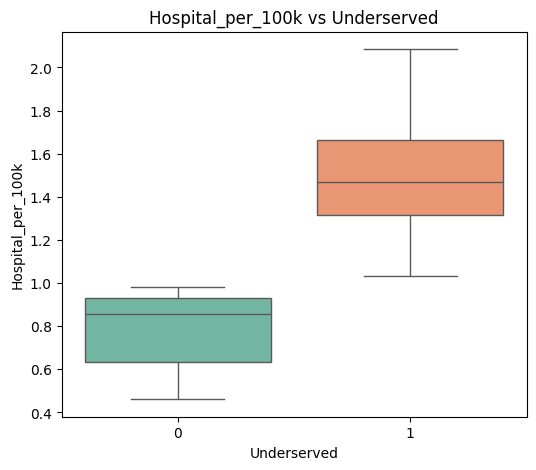

In [15]:
fynesse.assess.plot_hospitals_per_100k(merged_data)

#### **2.4.2 Correlation Analysis**

Correlation analysis is a necessary in the assessment process because it provides insights into the relationships between variables within the dataset. By examining how features move together—whether positively or negatively—it becomes possible to identify which factors are most closely associated with the target variable *underserved*


In [16]:
%%capture
# corr_matrix_preproccesed = fynesse.assess.analyse_correlation(preprocessed_data)
# corr_matrix _geo_featurec= fynesse.assess.analyse_correlation(df_osm_geo_features)
corr_matrix_merged = fynesse.assess.analyse_correlation(merged_data)

In [17]:
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix_merged, cmap='coolwarm', annot=True)
# plt.title("Correlation Matrix")
# plt.savefig("correlation_matrix_heatmap.png", dpi=300, bbox_inches='tight')
# plt.show()


display(corr_matrix_merged.style.background_gradient(cmap='coolwarm'))


,amenity:hospital,amenity:clinic,amenity:pharmacy,healthcare:doctor,healthcare:centre,amenity:dentist,amenity:nursing_home,building,amenity:school,amenity:place_of_worship,Total_Population19,Population Density,Facility Count,Hospital_per_100k,Underserved
amenity:hospital,1.000000,0.671118,0.625909,0.328418,-0.008447,0.541536,0.173286,0.415140,0.665837,0.632357,0.464991,0.477065,0.425998,-0.042268,-0.130588
amenity:clinic,0.671118,1.000000,0.806334,0.492375,-0.011066,0.479678,0.074310,0.373638,0.791552,0.714873,0.489309,0.500630,0.419105,-0.085885,-0.228147
amenity:pharmacy,0.625909,0.806334,1.000000,0.342058,-0.011275,0.441179,0.056683,0.407940,0.812012,0.831145,0.417954,0.425318,0.384503,-0.018654,-0.183503
healthcare:doctor,0.328418,0.492375,0.342058,1.000000,-0.005034,0.375281,-0.009914,0.044652,0.270316,0.250436,0.235584,0.236574,0.197895,-0.037243,-0.105213
healthcare:centre,-0.008447,-0.011066,-0.011275,-0.005034,1.000000,-0.008886,-0.003695,-0.021752,-0.015475,-0.015942,0.000334,-0.017820,-0.033140,-0.067854,-0.064775
amenity:dentist,0.541536,0.479678,0.441179,0.375281,-0.008886,1.000000,-0.017498,0.124157,0.288996,0.354383,0.355808,0.328567,0.299266,-0.089920,-0.153688
amenity:nursing_home,0.173286,0.074310,0.056683,-0.009914,-0.003695,-0.017498,1.000000,0.264438,0.032021,0.052503,-0.046172,-0.043085,-0.030521,0.056274,0.057038
building,0.415140,0.373638,0.407940,0.044652,-0.021752,0.124157,0.264438,1.000000,0.432028,0.482580,0.406100,0.370786,0.359170,-0.035205,-0.141112
amenity:school,0.665837,0.791552,0.812012,0.270316,-0.015475,0.288996,0.032021,0.432028,1.000000,0.867967,0.520141,0.526902,0.453173,-0.083963,-0.206060
amenity:place_of_worship,0.632357,0.714873,0.831145,0.250436,-0.015942,0.354383,0.052503,0.482580,0.867967,1.000000,0.482081,0.499104,0.425480,-0.068205,-0.187212


#### **2.4.3 Feature Importance**

we evaluate how much each feature contributes to predicting the target variable, *underserved*. Feature importance helps identify which variables have the greatest influence on whether a county or location is categorized as underserved. By quantifying the relative contribution of each feature, we can distinguish between highly informative variables and those that add little value to the analysis. This process not only improves model performance by reducing noise and redundancy but also enhances interpretability, allowing policymakers and planners to understand the key drivers of service gaps.


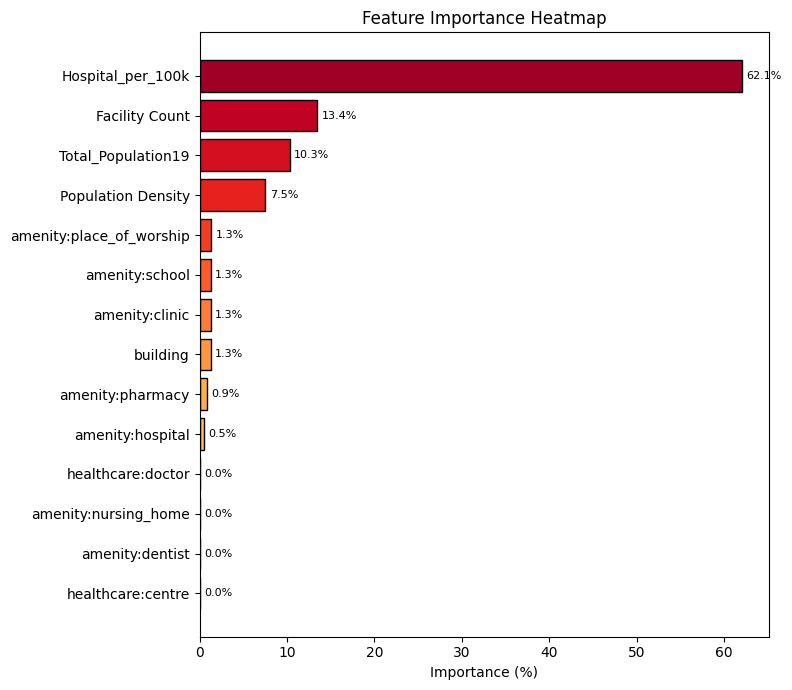

In [18]:
# rf_model, importances_df = fynesse.assess.plot_feature_importance_rf(preprocessed_data, target_col="Underserved")
rf_model, importances_df = fynesse.assess.plot_feature_importance_rf(merged_data, target_col="Underserved")


#### **2.4.4 Underserved distribution**

The function `fynesse.assess.plot_underserved_distribution()` visualizes the distribution of the target variable *Underserved* within the dataset. By plotting how many counties classified as underserved versus adequately served, it provides a quick overview of class balance. This is important for understanding whether the dataset is imbalanced, which can affect the reliability of subsequent modeling and analysis.


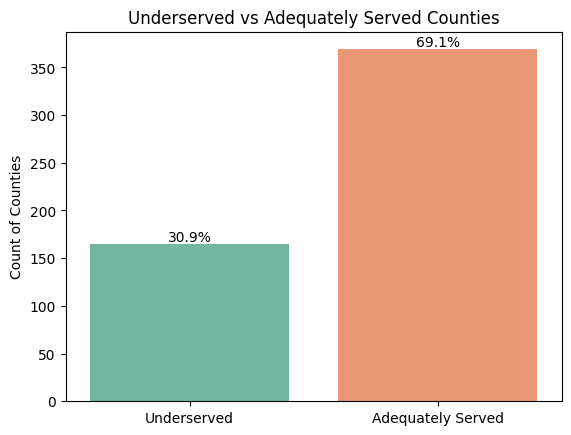

In [19]:
fynesse.assess.plot_underserved_distribution(merged_data,target_col='Underserved')

#### **2.4.5 Visualization of health facility locations across Kenya**

The function `fynesse.assess.plot_health_facilities()` generates a spatial visualization of health facility locations across Kenya, overlaying them on county boundary polygons. By combining the `df_health_facilities` dataset (facility attributes and coordinates) with the `gdf_counties` dataset (county boundaries), it produces a map that highlights how healthcare facilities are distributed geographically.



In [20]:
# fynesse.assess.plot_health_facilities(df_facilities=subset_health_facilities,gdf_counties=gdf_counties)

Spatial visualization of health facility locations across Kenya considering the type of facility

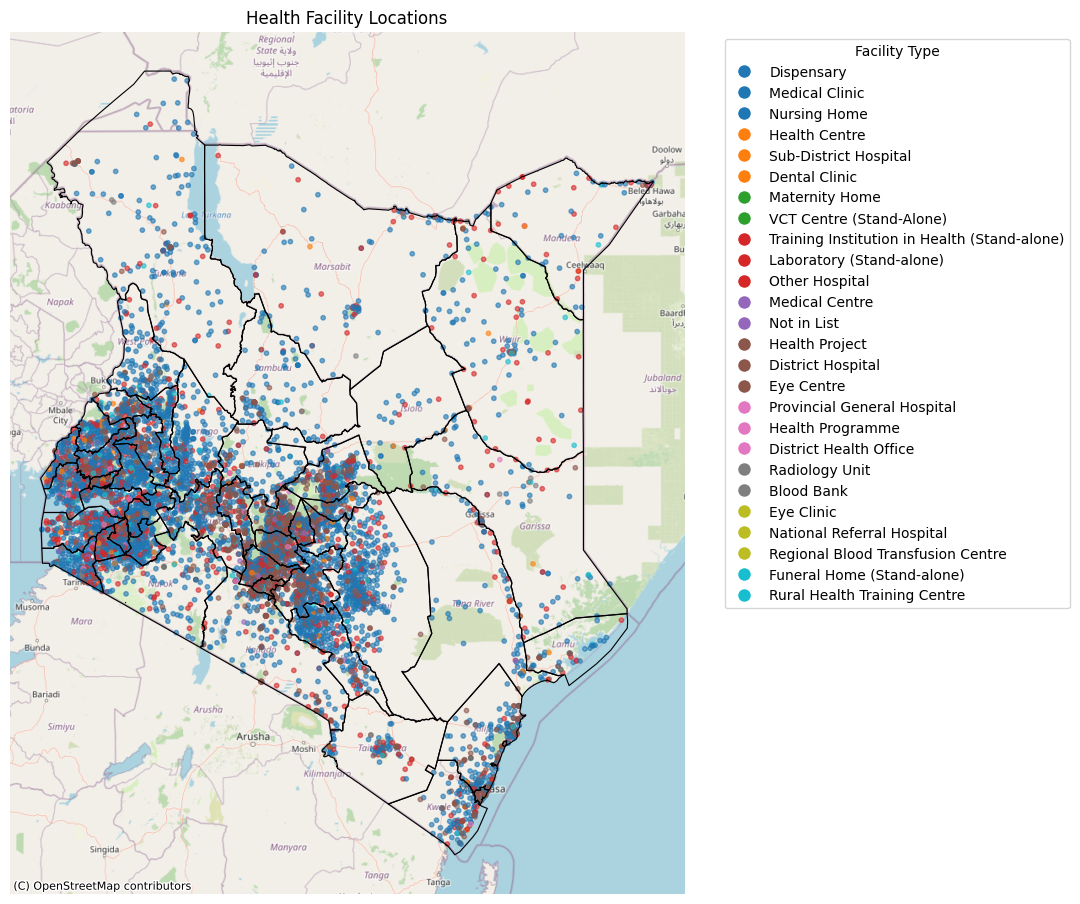

In [21]:
fynesse.assess.plot_health_facilities_byType(df_facilities=df_health_facilities,gdf_counties=gdf_counties)

Generate facility distribution maps for the first ten counties.

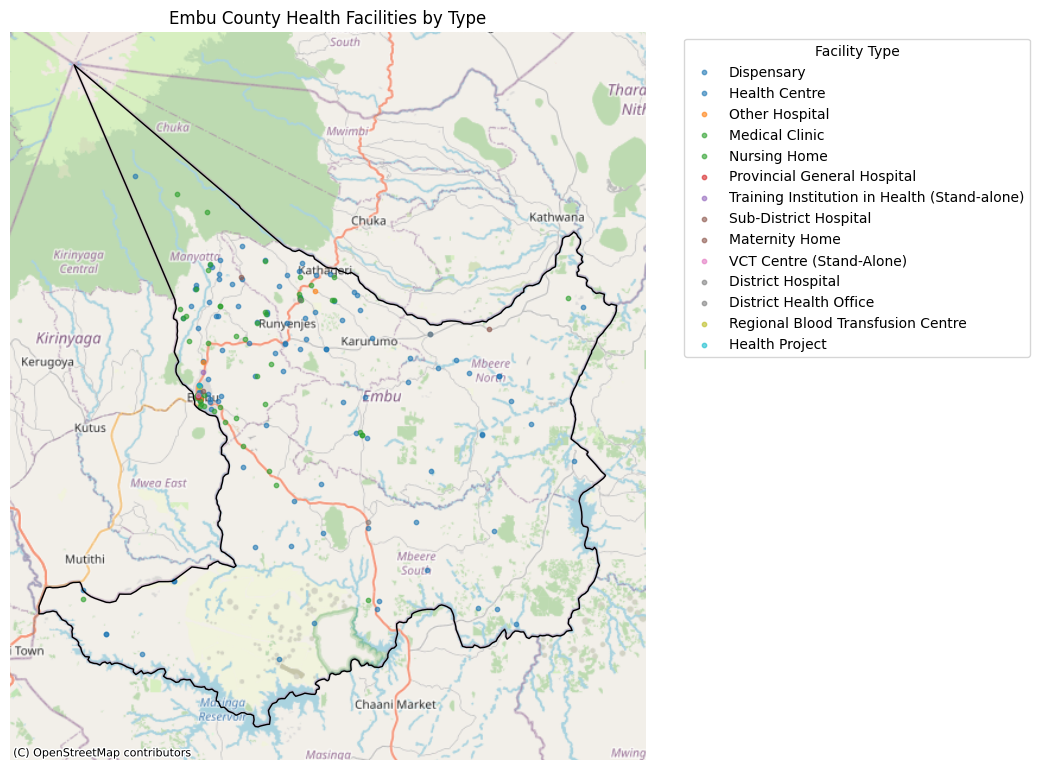

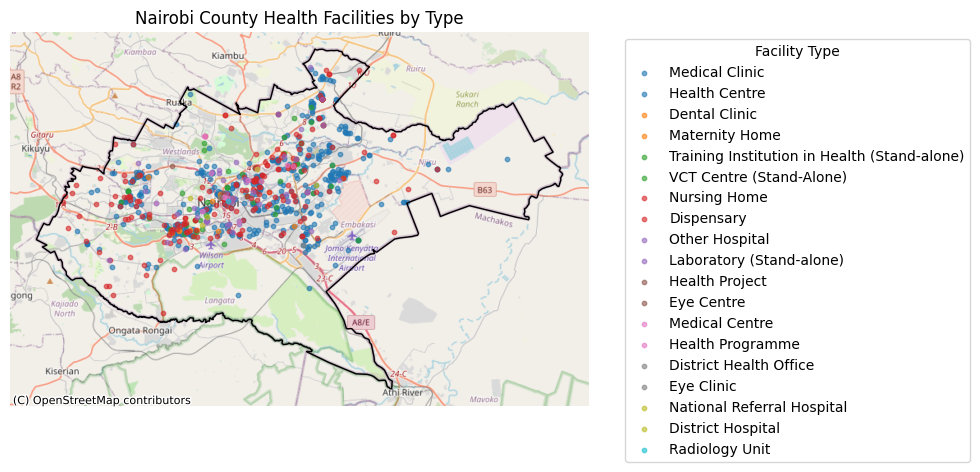

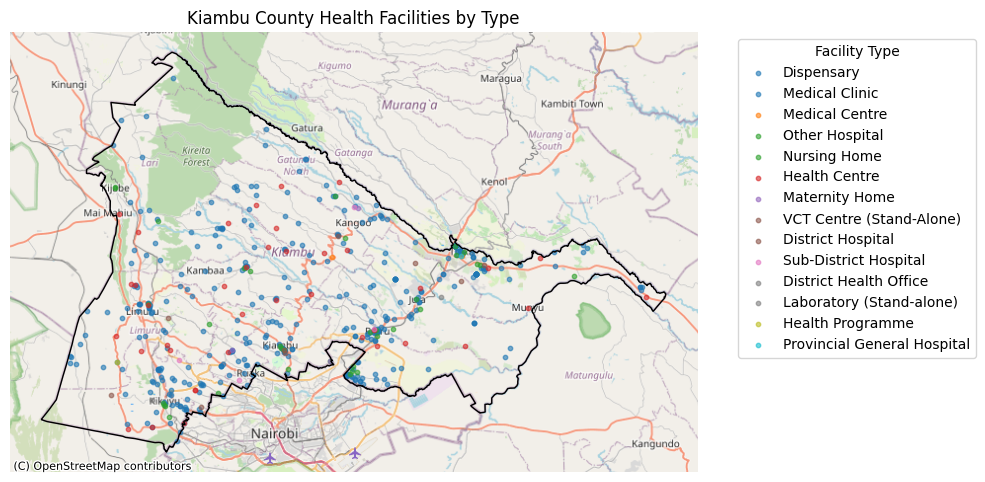

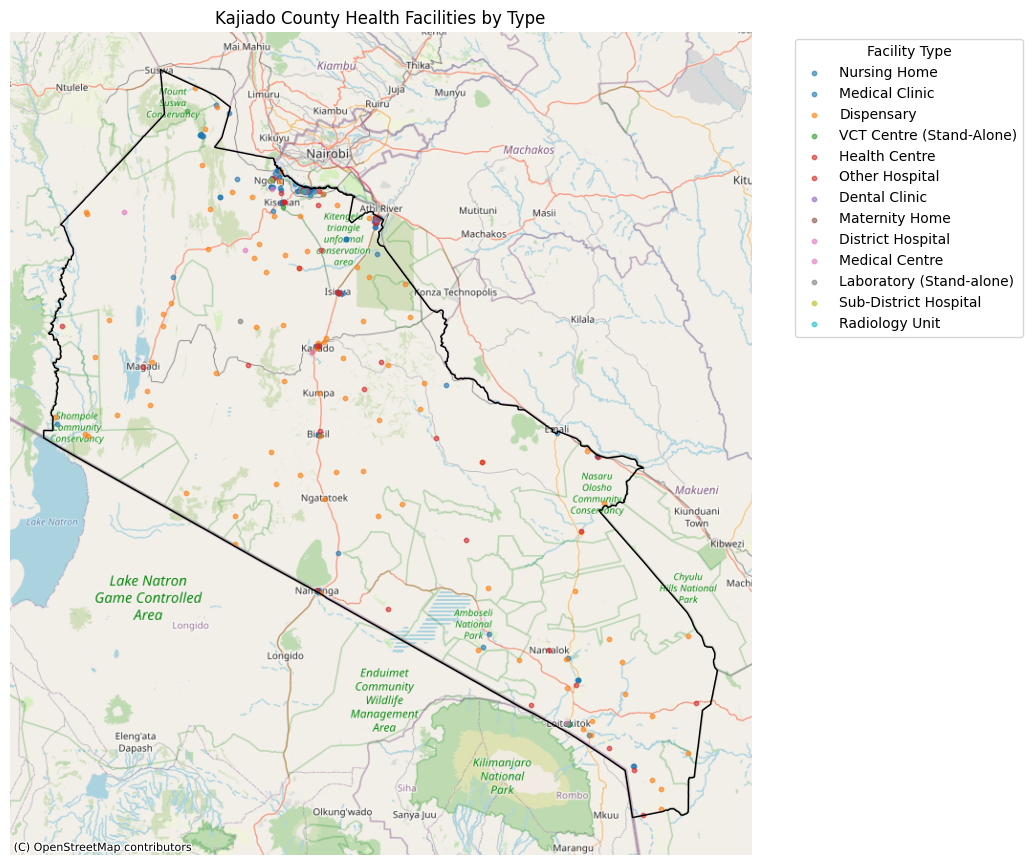

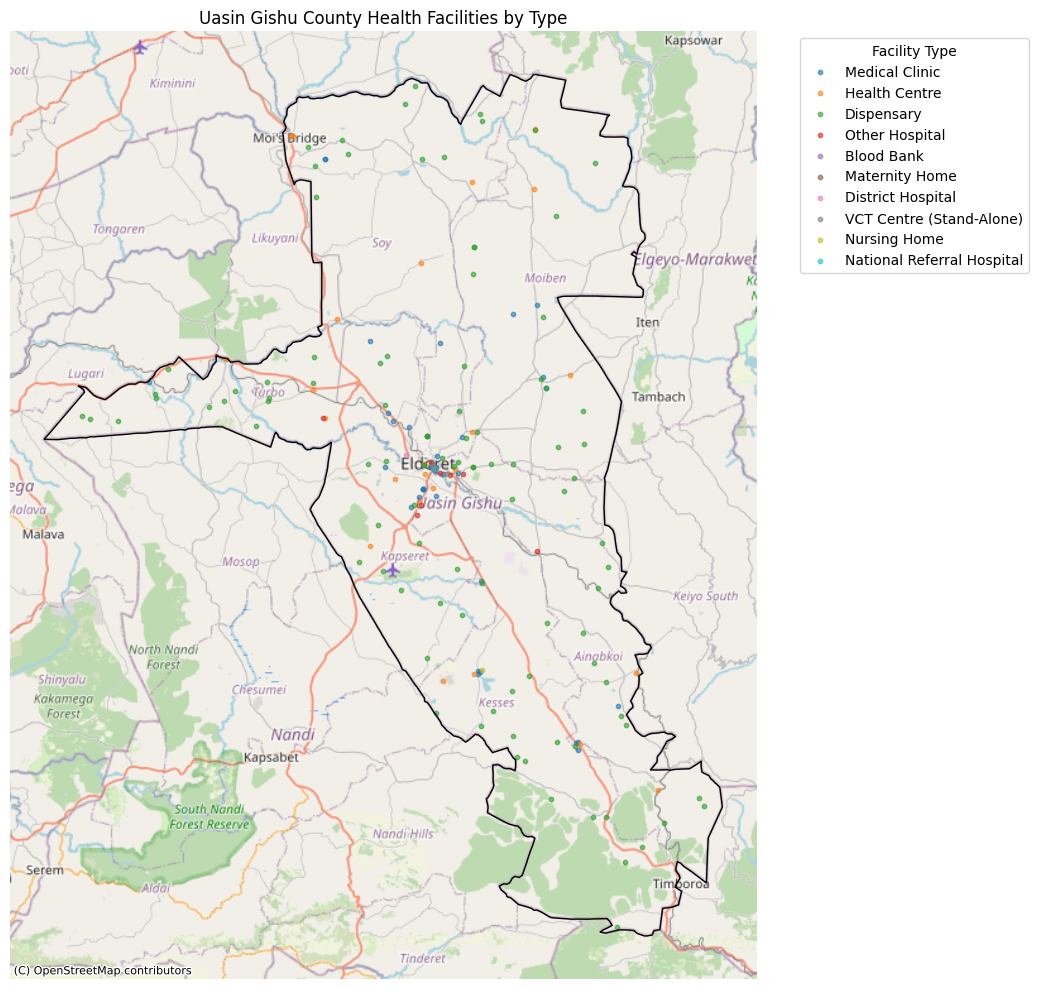

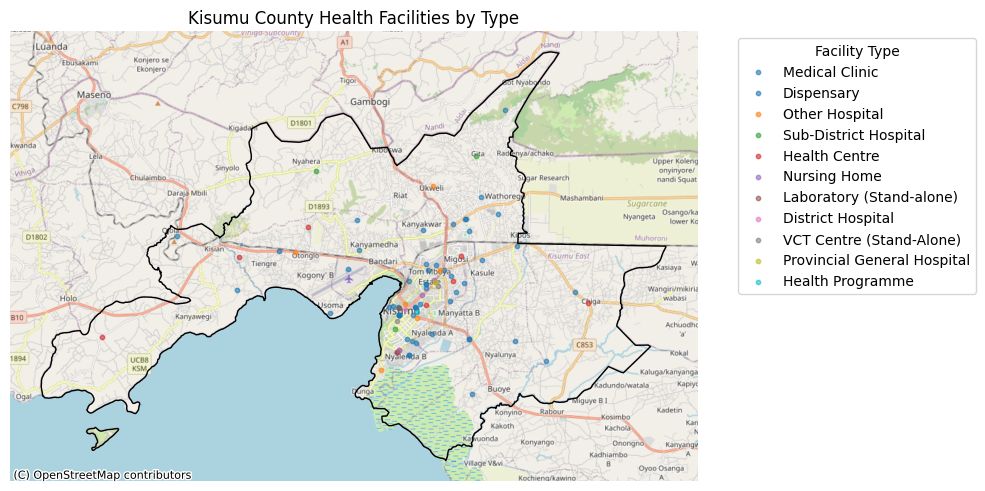

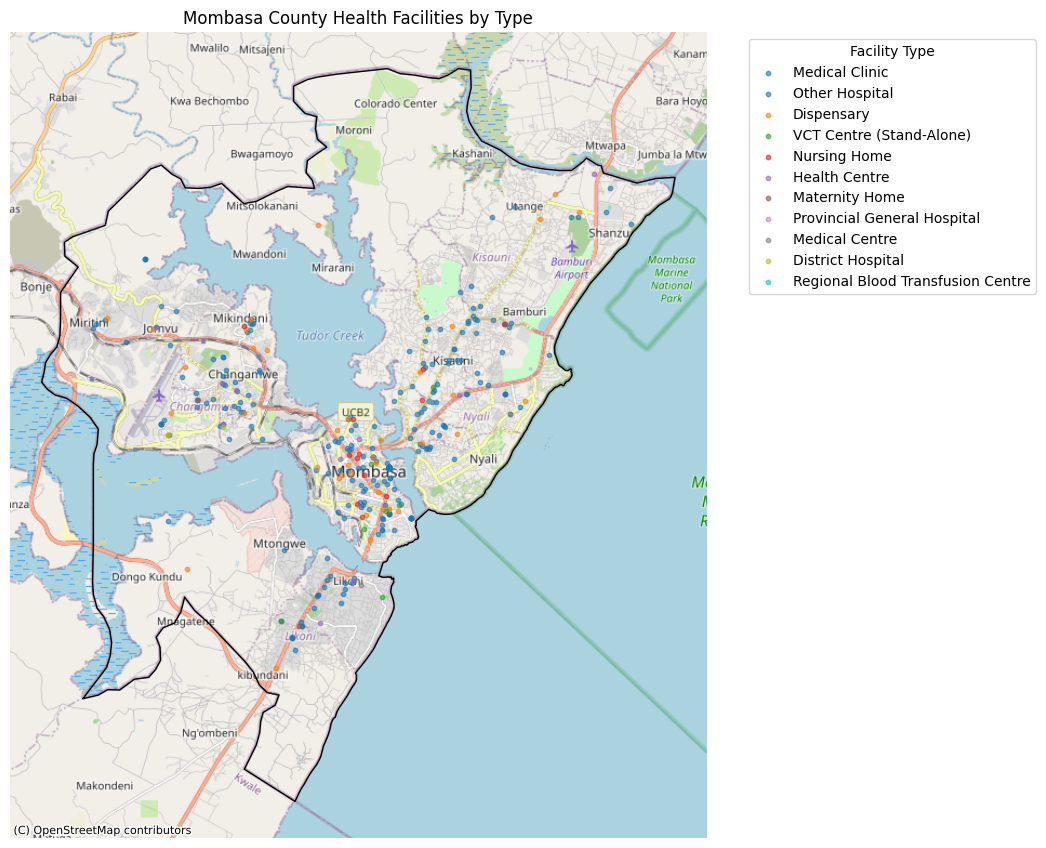

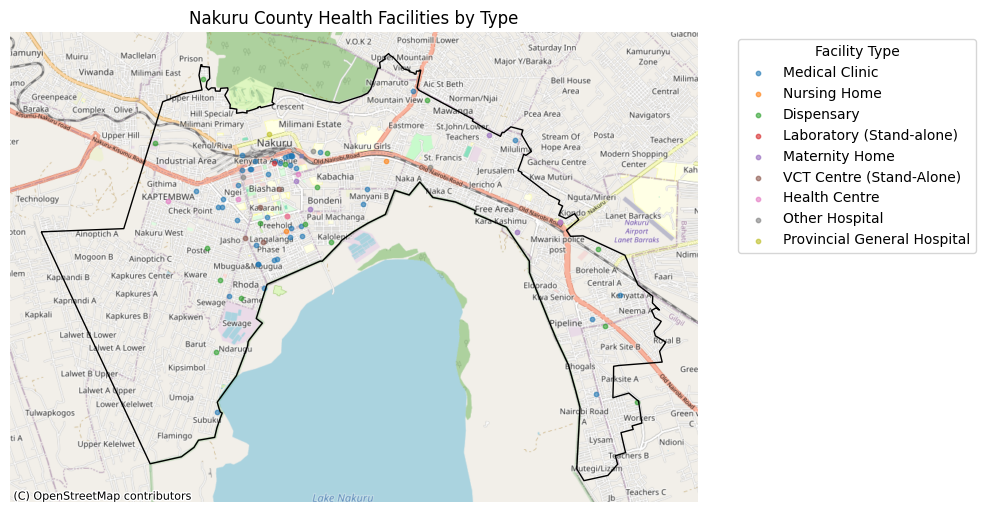

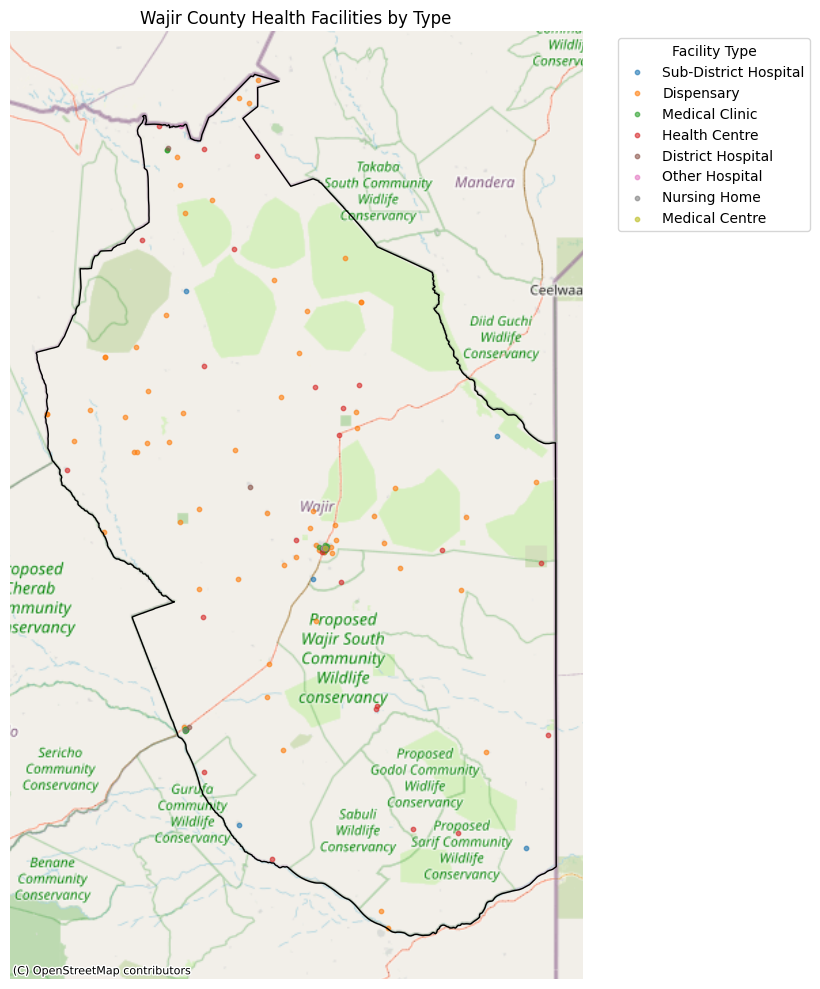

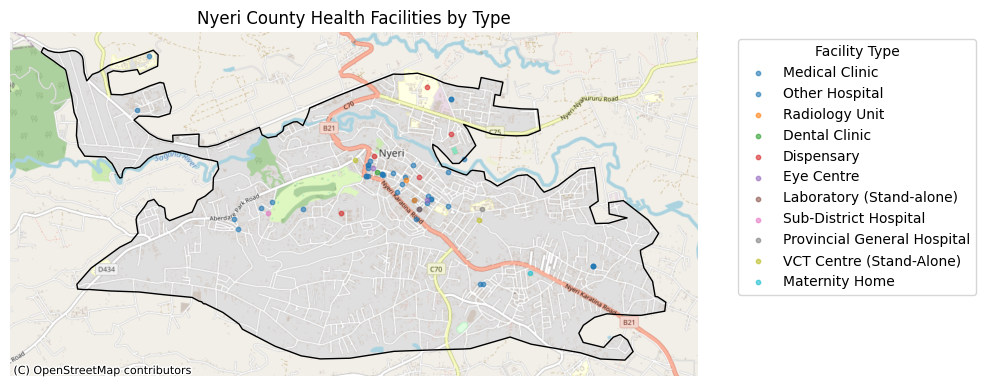

In [22]:
unique_counties = df_health_facilities["County"].dropna().unique()

# Loop through each county and plot
for county in unique_counties[:10]:
    print(" ")
    fynesse.assess.plot_county_facilities(county_name=county,df_facilities=df_health_facilities)

#***Address***

We prepare the dataset for modeling by separating the features (**X**) and the target (**y**). The target variable, *Underserved*, is removed from the feature set because it represents the outcome we want to predict. Additionally, columns such as *healthcare\:doctor*, *amenity\:nursing\_home*, *amenity\:dentist*, and *healthcare\:centre* are excluded from the features as their importance in predictiong the target variable is zero. The remaining columns in **X** are then converted to numeric values using `pd.to_numeric(errors="coerce")`, which ensures that all non-numeric entries are handled gracefully by coercing them into `NaN`. On the other hand, the target variable **y** is defined as the *Underserved* column and explicitly cast to integers, where `0` indicates a underserved region and `1` indicates an well-served region. This setup ensures that the model is trained only on relevant numeric predictors while keeping the target variable clearly defined for classification.


In [23]:
X = merged_data.drop(columns=["Underserved", "healthcare:doctor", "amenity:nursing_home","amenity:dentist","healthcare:centre"]).apply(
    pd.to_numeric, errors="coerce")

y = merged_data["Underserved"].astype(int)

The dataset is split into training and testing subsets using the `train_test_split` function. The features (**X**) and target (**y**) are divided so that 80% of the data is used for training the model, while the remaining 20% is set aside for testing. The parameter `random_state=42` is included to ensure reproducibility — meaning the split will always be the same whenever the code is run.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **3.1 Logistic Regression**

### **3.1.1 Training**

The logistic regression classifier is trained using the **training data**. The function `train_underserved_classifier` takes the feature set (`X_train`) and the corresponding labels (`y_train`) as inputs. Internally, it applies **feature scaling** with `StandardScaler` to normalize the data, ensuring that variables on different scales do not disproportionately influence the model. After scaling, a **logistic regression model** is fit to the training data. The resulting trained pipeline is stored in the variable `underserved_clf`, which can then be used for making predictions.


In [25]:
underserved_clf = address.train_logistic_classifier(X_train, y_train)

### **3.1.2 Evaluation**

Trained classifier `underserved_clf` is then evaluated on the `X_test` and `y_test`. The function `evaluate_underserved_classifier` first uses the model to generate predictions (`y_pred`) for the test features. It then prints a **classification report**, which summarizes key performance metrics such as precision, recall, F1-score, and accuracy for each class. These metrics provide insights into how well the model distinguishes between **underserved** and **well-served** counties. Finally, the function returns the predicted labels (`y_pred`) as a Pandas Series, which can be used for further analysis or visualization.


In [26]:
y_pred = address.evaluate_logistic_classifier(underserved_clf, X_test, y_test)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        33
           1       1.00      0.96      0.98        74

    accuracy                           0.97       107
   macro avg       0.96      0.98      0.97       107
weighted avg       0.97      0.97      0.97       107



In [27]:
X_train.loc['Uasin Gishu']

,amenity:hospital,amenity:clinic,amenity:pharmacy,building,amenity:school,amenity:place_of_worship,Total_Population19,Population Density,Facility Count,Hospital_per_100k
County,,,,,,,,,,
Uasin Gishu,0,0,0,34,0,0,1163186,343,12,1.031649
Uasin Gishu,1,0,0,35,5,3,1163186,343,12,1.031649
Uasin Gishu,3,0,0,285,0,0,1163186,343,12,1.031649
Uasin Gishu,11,0,0,693,4,3,1163186,343,12,1.031649
Uasin Gishu,7,0,0,967,3,5,1163186,343,12,1.031649
Uasin Gishu,8,0,0,891,2,7,1163186,343,12,1.031649
Uasin Gishu,1,0,0,878,0,0,1163186,343,12,1.031649
Uasin Gishu,11,0,0,1145,4,5,1163186,343,12,1.031649


In [28]:
y_test.loc['Uasin Gishu']

,Underserved
County,
Uasin Gishu,1
Uasin Gishu,1
Uasin Gishu,1
Uasin Gishu,1


In [29]:
y_pred.loc['Uasin Gishu']

,Predicted
County,
Uasin Gishu,0
Uasin Gishu,0
Uasin Gishu,1
Uasin Gishu,0


- **Observations**

The model achieved **97% accuracy overall**. For **underserved counties (class 0)**, it correctly identified all of them (recall = 1.00) with strong precision (0.92). For **well-served counties (class 1)**, it had perfect precision (1.00), meaning none were wrongly labeled as underserved, while recall was slightly lower at 0.96, indicating a few well-served counties were missed. In summary, the model is very reliable at distinguishing underserved from well-served counties, with only minor errors leaning toward overestimating underserved areas.




### **3.1.3 Confusion Matrix**

The confusion matrix provides a clear visualization of how well the underserved classifier distinguishes between underserved (class 0) and well-served (class 1) counties.


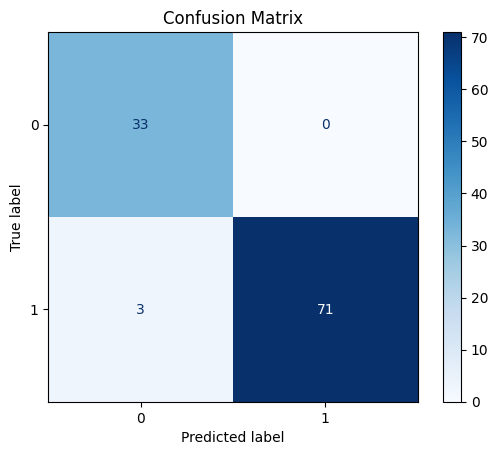

In [30]:
fynesse.address.plot_underserved_confusion_matrix(y_test, y_pred, labels=underserved_clf.classes_)


The `visual_predictions` function produces two side-by-side maps that visually compare the actual and predicted classifications of counties. On the left, the ground truth map highlights underserved counties in red and well-served counties in green, based on the test dataset. On the right, the prediction map uses the same color scheme to display the model’s outputs while outlining misclassified counties in yellow with hatching to clearly indicate where the model’s predictions diverge from reality. Both maps are overlaid on an OpenStreetMap basemap to provide geographic context.


/content/mlfc_miniproject/fynesse/address.py:282: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  map_data["Misclassified"] = map_data["Misclassified"].fillna(False).astype(bool)


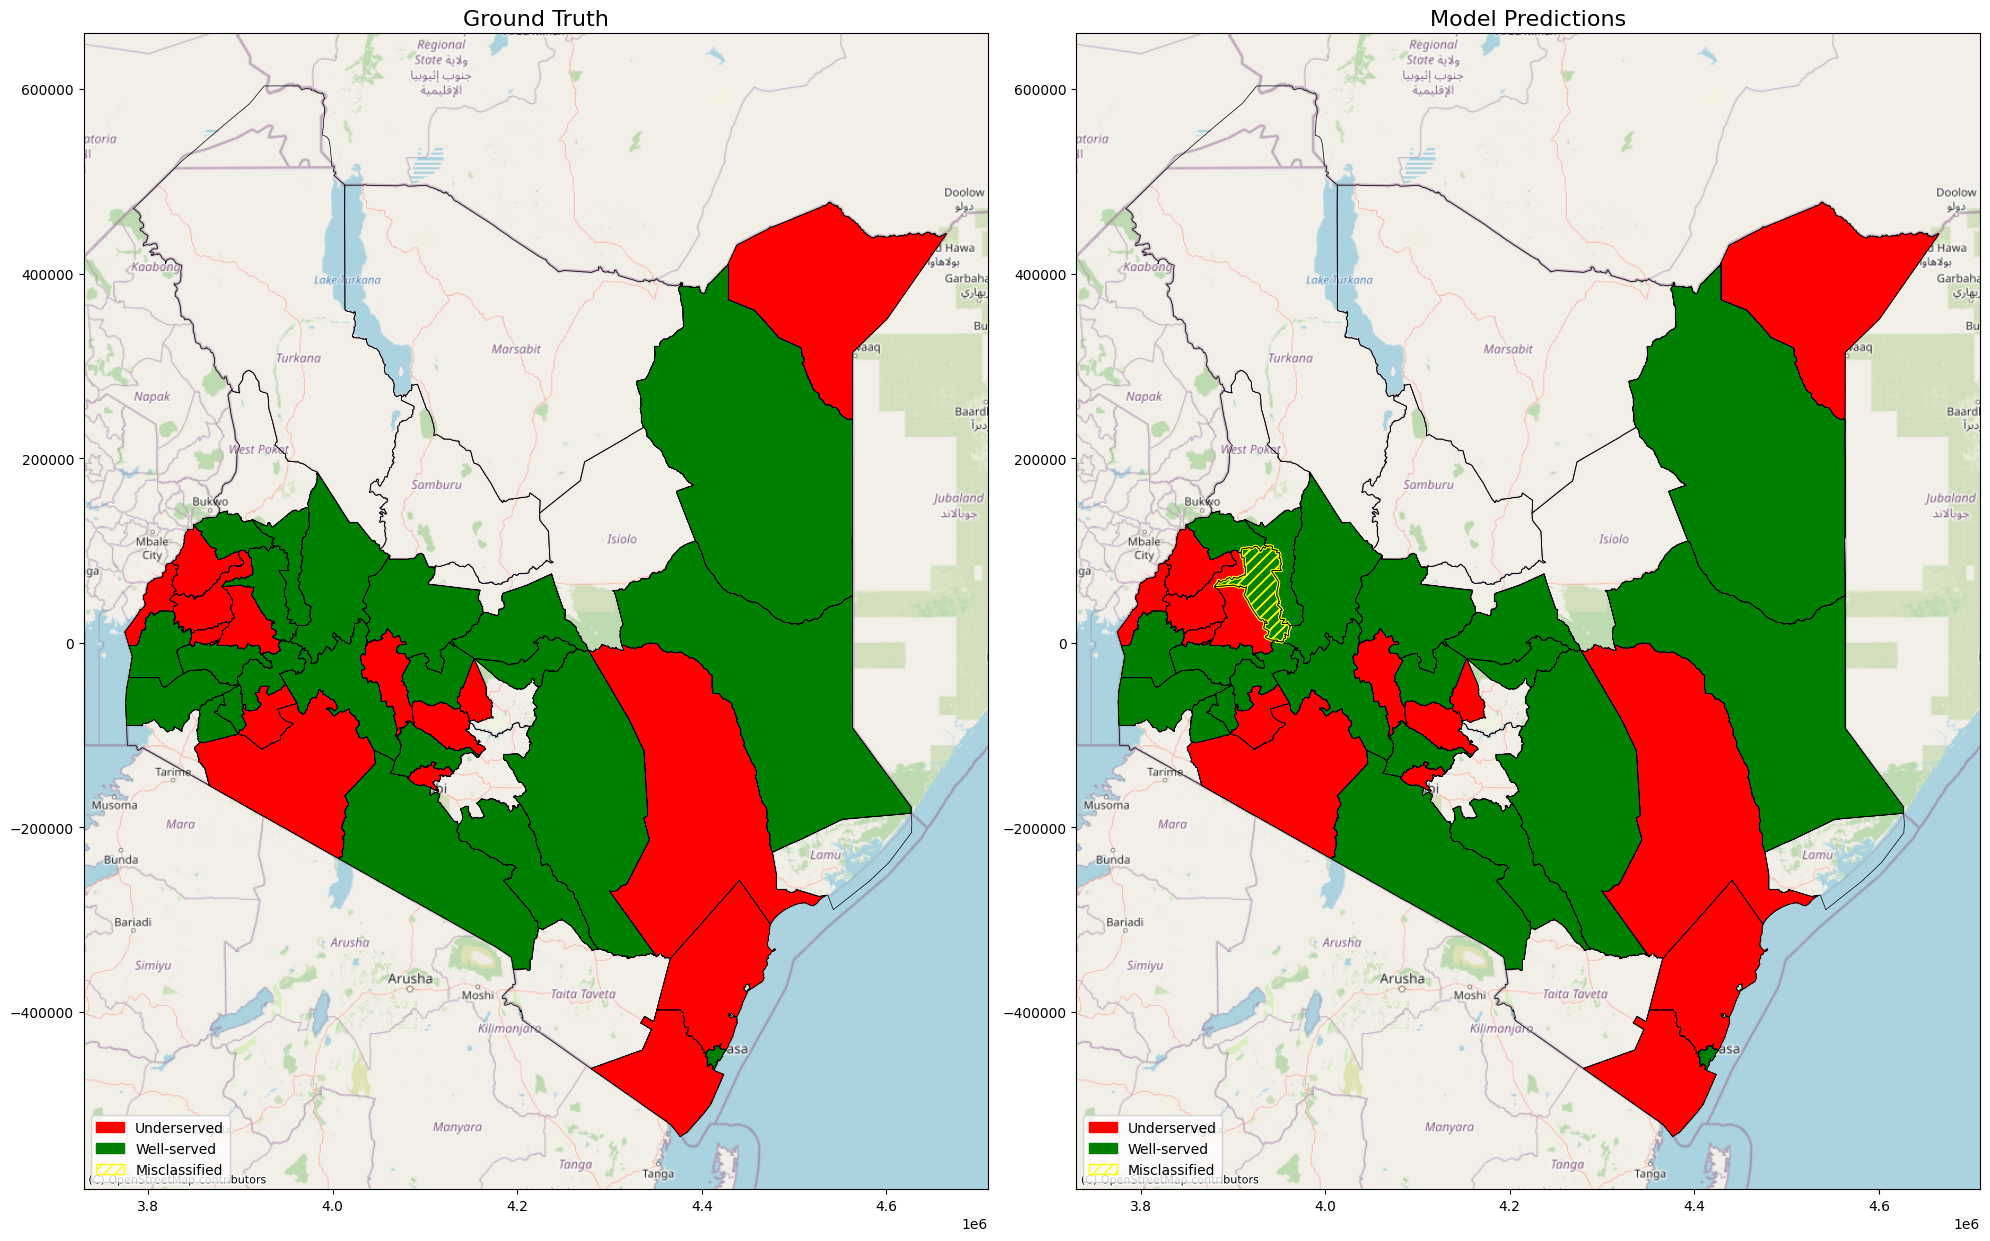

In [31]:
address.visual_predictions(
    gdf_counties=gdf_counties,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    basemap=ctx.providers.OpenStreetMap.Mapnik,
    zoom=7
)

- **Observation**

The visualization shows that almost all counties were classified correctly, with just one exception. Uasin Gishu county that is actually underserved was misclassified by the model as well-served, highlighted with a yellow hatched outline. This indicates that while the model performs strongly overall, it still struggles with a few edge cases that could impact decision-making.


## **3.4 Naive Bayes**

### **3.4.1 Training the NB model**

We train **Naive Bayes model** using the training dataset. The function `train_naive_bayes` from the module fits a **Gaussian Naive Bayes classifier** on the features (`X_train`) and labels (`y_train`). Once trained, the resulting `nb_model` can be used to make predictions or evaluate performance on the test dataset.


In [32]:
nb_model = fynesse.address.train_naive_bayes(X_train, y_train)

### **3.4.2 Evaluation**

The trained **Naive Bayes model** is evaluates on the test dataset. The function `evaluate_naive_bayes` calculates the **accuracy** of the model’s predictions and the **average predicted probability** that a county belongs to the specified class. The result is a concise summary showing how confidently the model predicts underserved areas and how well it performs overall.


In [33]:
fynesse.address.evaluate_naive_bayes(nb_model, X_test, y_test, 0)

'Probability of county being 0: 0.189 | Overall accuracy: 0.692'

- **Observation**

The Naive Bayes model achieved an **overall accuracy of 69.2%**. However, the **average probability of a county being underserved (class 0)** was only **18.9%**, suggesting that the model tends to underpredict underserved regions. This indicates that while the model has moderate accuracy, it struggles to assign strong confidence to identifying underserved counties.


### **3.4.3 Plot ROC curve**

The ROC curve for the Naive Bayes model provides a visual assessment of how well the classifier distinguishes between underserved and well-served counties across different probability thresholds. In this plot, the **true positive rate (sensitivity)** is plotted against the **false positive rate (1 – specificity)**, with the **area under the curve (AUC)** indicating overall model performance. The AUC is closer to 0.5 than 1, confirming that its ability to separate underserved from well-served counties is limited compared to the logistic regression classifier.


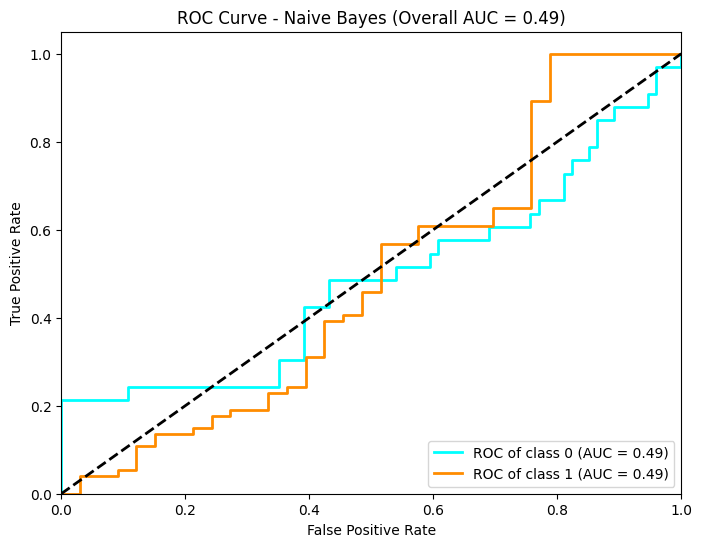

In [34]:
fynesse.address.plot_roc_curve(nb_model,X_test,y_test)